# UK Economic Pulse

## Goal: understand what the hell is going on with the economy

### Methods: 

### 1. Trend the latest macro variables across 4 broad areas

#### 1.1 Economic Activity

GDP (US), 
GDP (UK), 
House Prices (UK),
Retail Sales

#### 1.2 Inflation Pressure

CPI (UK), 
Real Wages (UK), 
Unemployment (UK), 
Consumer Confidence, 
Labour Participation

#### 1.3 Financial Conditions

Base Rate (UK), 
10Y Yield (UK), 
10Y Yield (US), 
Credit Spreads (add!)

#### 1.4 Commodity Prices

Oil, 
Gold, 
Silver, 
Copper, 
Natural Gas

### 2. Devise a composite metric of these to track the actual pulse of the economy: The Economic Pulse Index (EPI)

Growth Engine (Demand). 
This tells you: Is the economy breathing in or suffocating?

Pressure System (Consumers Under Strain). 
This tells you: Are people getting richer or just surviving?

Liquidity & Cost of Money
This tells you: Is money flowing or frozen?

Global Stress Signals (Commodities)
This tells you: Is the world heating up or cooling down?

For each metric:

Convert to z-score (standardised vs history)
Smooth (3-month average)
Directional bias:
Growth up = good
Inflation up = bad
Rates up = tightening
Commodities depend (contextual)

Then:

EPI = weighted sum of all 4 pillars

Now you’ve got:

A single number
A trend
A story

### 3. Step 3: Give it a voice

#### The Headline (1 sentence)

“The UK economy is running hot, but consumers are quietly breaking.”

#### The Shift (What changed this month?)
Growth: ↑ or ↓
Pressure: ↑ or ↓
Liquidity: tightening/loosening
Commodities: signalling expansion/contraction

#### The Tension (this is where signal lives)
Growth ↑ but real wages ↓
→ “Expansion without participation”
Inflation ↓ but yields ↑
→ “Markets don’t believe the victory narrative”

#### The Implication (force a perspective)
For workers
For businesses
For investors

### Step 4: Overlay Reality (data alone is sterile)

Separate yourself from every dashboard clown.

Tie your signals to real events:

Bank of England decisions
Federal Reserve stance
Elections, wars, supply shocks
AI layoffs, housing policy, energy crises

👉 Example:

“Despite falling CPI, bond markets are pricing in higher rates following Bank of England rhetoric—suggesting inflation fears aren’t dead, just dormant.”

### Step 5: Build Your Signature Angles (repeatable alpha)

You don’t need 100 insights. You need 5 you revisit relentlessly:

1. “The Illusion Gap”

Growth vs Real Wages
→ Are headlines lying to people?

2. “The Squeeze Index”

Inflation + Rates + Wages
→ How painful is life, really?

3. “Liquidity Tide”

Rates + Yields
→ Is capital entering or exiting the system?

4. “Global Stress Map”

Commodities
→ Is pressure building beneath the surface?

5. “Confidence vs Reality”

Consumer Confidence vs actual spending
→ Are people delusional or early?

Build a system that forces you to answer, every month:

What changed?
Why does it matter?
Who wins?
Who loses?

# Step 1: Get the Macro Data

In [11]:
# UK Economic Pulse - Building the Core Logic Step by Step

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
import openpyxl


# Need pandas to connect to dataframes
# Matplotlib is sufficient for simple visualisations
# Fred and Yahoo Finance will give us the data

import io
import re
import requests


In [3]:
# FRED_API_KEY = os.getenv("FRED_API_KEY")  # or paste your key as a string for now
FRED_API_KEY = '0acae73adc29df31d82dce5320829f70'
fred = Fred(api_key=FRED_API_KEY)

# Why is it cleaner to use an environment variable?

# Step 1.1: Get GDP / Economic Activity

We get data from FRED's API, published quarterly

In [4]:
gdp = fred.get_series("NGDPRSAXDCGBQ")
gdp.head(), gdp.tail()

# Date index
# Float values
# Updated quarterly

(1955-01-01    145457.0
 1955-04-01    145551.0
 1955-07-01    147995.0
 1955-10-01    147119.0
 1956-01-01    148955.0
 dtype: float64,
 2024-10-01    699094.0
 2025-01-01    703655.0
 2025-04-01    705117.0
 2025-07-01    705681.0
 2025-10-01    706067.0
 dtype: float64)

In [5]:
print(type(gdp))
print(gdp.index.min(), gdp.index.max())
print(gdp.isna().sum())
print(pd.infer_freq(gdp.index))

# Class: Series
# Inferred frequency: Quarters
# No gaps

<class 'pandas.core.series.Series'>
1955-01-01 00:00:00 2025-10-01 00:00:00
0
QS-OCT


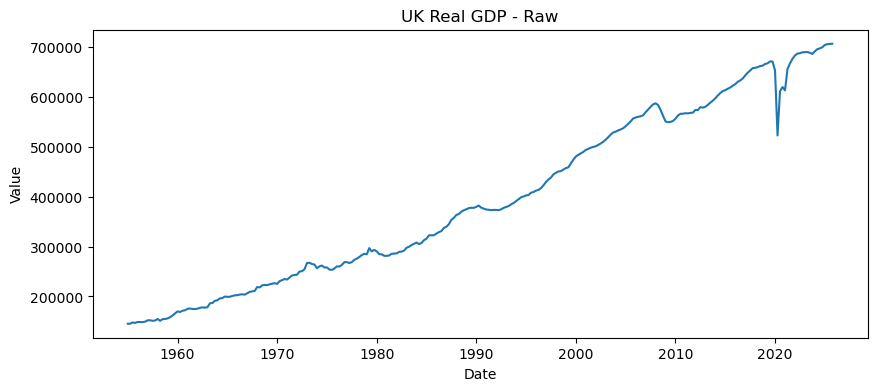

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(gdp.index, gdp.values)
plt.title("UK Real GDP - Raw")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Clear recessions in almost every decade, with the worst being the pandemic, by far

In [7]:
# -----------------------------
# 4) ONS Retail Sales Volume Index
# Sheet: KPSA (Seasonally Adjusted), headers at row 7
# -----------------------------

def get_uk_retail_sales_ons() -> pd.Series:
    url = "https://www.ons.gov.uk/file?uri=/businessindustryandtrade/retailindustry/datasets/retailsalesindexreferencetables/current/mainreferencetables.xlsx"

    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df = pd.read_excel(io.BytesIO(r.content), sheet_name="KPSA", header=6)

    time_col = "Time Period"
    value_col = "All retailing including automotive fuel [note1]"
    df = df[[time_col, value_col]].copy()

    # Truncate before the 'Revision to index numbers' section
    revision_mask = df[time_col].astype(str).str.contains("Revision", case=False, na=False)
    if revision_mask.any():
        df = df.iloc[:revision_mask.values.argmax()]

    # Drop blank / metadata rows
    df = df[df[time_col].notna()]
    df = df[df[time_col].astype(str).str.strip().ne("")]

    # Parse 'yyyy-mmm' (e.g. '1996 Jan') to datetime
    date_str = df[time_col].astype(str).str.strip().str.replace("-", " ")
    df["date"] = pd.to_datetime(date_str, format="%Y %b", errors="coerce")

    df["value"] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["date", "value"])

    # Sort chronologically on datetime BEFORE converting to string
    df = df.sort_values("date")
    return df.set_index("date")["value"]

# Step 1.2: Get Oil Prices

We get oil prices from FRED's API, published daily

In [8]:
oil = fred.get_series("DCOILBRENTEU")

# Why is it useful to compare mixed frequencies?
# What problem will this create later?

In [ ]:
# Commodity Prices — Gold, Silver, Copper, Natural Gas
# All sourced from COMEX/NYMEX futures via yfinance, daily

gold    = yf.download('GC=F', start='2000-01-01', progress=False)['Close'].squeeze()  # USD/troy oz
silver  = yf.download('SI=F', start='2000-01-01', progress=False)['Close'].squeeze()  # USD/troy oz
copper  = yf.download('HG=F', start='2000-01-01', progress=False)['Close'].squeeze()  # USD/lb
nat_gas = yf.download('NG=F', start='2000-01-01', progress=False)['Close'].squeeze()  # USD/MMBtu

# In many regions, Gas sets the marginal price of electricity.

# Market Indicators — Semiconductors, Uranium, US Dollar
# SOX & DXY: yfinance (daily)
# Trade-Weighted USD: FRED DTWEXBGS (daily, Federal Reserve)

sox     = yf.download('^SOX',     start='2000-01-01', progress=False)['Close'].squeeze()  # PHLX Semiconductor Index
uranium = yf.download('URA',      start='2009-01-01', progress=False)['Close'].squeeze()  # Global X Uranium ETF
dxy     = yf.download('DX-Y.NYB', start='2000-01-01', progress=False)['Close'].squeeze()  # ICE US Dollar Index
twusd   = fred.get_series('DTWEXBGS')                                                      # Nominal Broad Trade-Weighted USD

for s in [gold, silver, copper, nat_gas, sox, uranium, dxy]:
    s.index = pd.to_datetime(s.index)

print('Gold    last date:', gold.last_valid_index().date())
print('Silver  last date:', silver.last_valid_index().date())
print('Copper  last date:', copper.last_valid_index().date())
print('Nat Gas last date:', nat_gas.last_valid_index().date())
print('SOX      last date:', sox.last_valid_index().date())
print('Uranium  last date:', uranium.last_valid_index().date())
print('DXY      last date:', dxy.last_valid_index().date())
print('TW USD   last date:', twusd.last_valid_index().date())



Gold    last date: 2026-04-17
Silver  last date: 2026-04-17
Copper  last date: 2026-04-17
Nat Gas last date: 2026-04-17
SOX      last date: 2026-04-17
Uranium  last date: 2026-04-17
DXY      last date: 2026-04-17
TW USD   last date: 2026-04-10


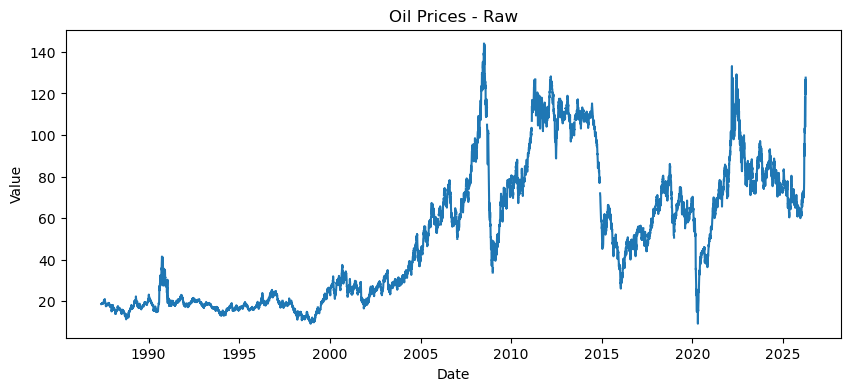

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(oil.index, oil.values)
plt.title("Oil Prices - Raw")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Massive increease since the turn of the century
# Steady incline since 2025 briefly impacted by the pandemic

# Step 1.3: Get UK Inflation / Wage Data

We extract a csv from ONS, generally published on the fourth week of every month

In [23]:
import re
import pandas as pd
import requests
import io

# -----------------------------
# 1) ONS CPI (index level)
# Series: D7BT = CPI INDEX 00: ALL ITEMS 2015=100
# Source dataset: MM23
# -----------------------------

def get_uk_cpi_index_ons() -> pd.Series:
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23"
    
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text))

    # Rename the two columns into something sane
    df.columns = ["raw_date", "raw_value"]

    # Keep only monthly rows like '1988 JAN'
    monthly_mask = df["raw_date"].astype(str).str.match(r"^\d{4} [A-Z]{3}$")
    df = df.loc[monthly_mask].copy()

    # Rename
    df = df.rename(columns={
        "raw_date": "date",
        "raw_value": "cpi_index"
    })

    # Parse fields
    df["date"] = pd.to_datetime(df["date"], format="%Y %b", errors="coerce")
    df["cpi_index"] = pd.to_numeric(df["cpi_index"], errors="coerce")

    # Clean up
    df = df.dropna(subset=["date", "cpi_index"]).sort_values("date")
    df = df.set_index("date")

    s = df["cpi_index"]
    s.name = "cpi_index"
    return s

In [24]:
# -----------------------------
# 2) ONS Nominal Wages (AWE Total Pay)
# Series: KAB9
# Source dataset: LMS
# -----------------------------

def get_uk_nominal_wages_ons() -> pd.Series:
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/employmentandlabourmarket/peopleinwork/earningsandworkinghours/timeseries/kab9/lms"
    
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text))

    df.columns = ["raw_date", "raw_value"]

    # Monthly rows like '2000 JAN'
    monthly_mask = df["raw_date"].astype(str).str.match(r"^\d{4} [A-Z]{3}$")
    df = df.loc[monthly_mask].copy()

    df = df.rename(columns={
        "raw_date": "date",
        "raw_value": "nominal_wage"
    })

    df["date"] = pd.to_datetime(df["date"], format="%Y %b", errors="coerce")
    df["nominal_wage"] = pd.to_numeric(df["nominal_wage"], errors="coerce")

    df = df.dropna(subset=["date", "nominal_wage"]).sort_values("date")
    df = df.set_index("date")

    s = df["nominal_wage"]
    s.name = "nominal_wage"
    return s

def get_uk_real_wages(cpi_index: pd.Series, wages: pd.Series) -> pd.Series:
    # Align dates
    df = pd.concat([cpi_index, wages], axis=1).dropna()

    # Real wage index (base-adjusted)
    df["real_wage"] = df["nominal_wage"] / df["cpi_index"] * 100

    s = df["real_wage"]
    s.name = "real_wage"
    return s

In [ ]:
def _parse_ons_monthly_series_from_csv(url: str, series_name: str) -> pd.Series:
    """
    Helper to pull an ONS timeseries CSV and return a clean monthly pandas Series.

    The ONS CSV usually comes with 2 columns:
    - raw_date like '1988 JAN' or '2025 NOV-JAN'
    - raw_value

    We keep only monthly rows like '1988 JAN' and ignore rolling-quarter labels
    like '2025 NOV-JAN' if they appear.
    """
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text))
    df.columns = ["raw_date", "raw_value"]

    # Keep rows like '1988 JAN'
    monthly_mask = df["raw_date"].astype(str).str.match(r"^\d{4}\s[A-Z]{3}$", na=False)
    df = df.loc[monthly_mask].copy()

    # Clean numeric values
    df["raw_value"] = pd.to_numeric(df["raw_value"], errors="coerce")
    df = df.dropna(subset=["raw_value"])

    # Parse dates
    df["date"] = pd.to_datetime(df["raw_date"], format="%Y %b")

    s = (
        df.set_index("date")["raw_value"]
        .sort_index()
        .rename(series_name)
    )

    return s

def get_uk_unemployment_rate_ons() -> pd.Series:
    """
    UK unemployment rate, aged 16 and over, seasonally adjusted (%).

    ONS series ID: MGSX
    Source dataset: Labour market statistics (LMS)
    """
    url = (
        "https://www.ons.gov.uk/generator?format=csv&uri="
        "/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/mgsx/lms"
    )
    return _parse_ons_monthly_series_from_csv(url, "uk_unemployment_rate")

def get_uk_labour_participation_rate_ons() -> pd.Series:
    """
    UK labour market participation rate, proxied as:
        100 - economic inactivity rate

    Uses ONS economic inactivity rate:
    UK, all, aged 16-64, seasonally adjusted (%)

    ONS series ID: LF2S
    """
    url = (
        "https://www.ons.gov.uk/generator?format=csv&uri="
        "/employmentandlabourmarket/peoplenotinwork/economicinactivity/timeseries/lf2s/lms"
    )

    inactivity = _parse_ons_monthly_series_from_csv(url, "uk_economic_inactivity_rate")
    participation = (100 - inactivity).rename("uk_labour_participation_rate")

    return participation

uk_unemployment_rate = get_uk_unemployment_rate_ons()
uk_labour_participation_rate = get_uk_labour_participation_rate_ons()

# Step 1.4: Get Bank of England Rates

We pull from the Bank's history page

In [29]:
import lxml

# -----------------------------
# 3) Bank of England policy rate
# Pull from the official Bank Rate history page
# -----------------------------

import io
import time
import requests
import pandas as pd

def get_boe_policy_rate(local_fallback_path=None) -> pd.Series:
    url = "https://www.bankofengland.co.uk/boeapps/database/Bank-Rate.asp"

    session = requests.Session()
    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0.0.0 Safari/537.36"
        ),
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-GB,en;q=0.9",
        "Referer": "https://www.bankofengland.co.uk/boeapps/database/",
        "Connection": "keep-alive",
    })

    # First hit the database home page to look less like a bot
    try:
        warmup = session.get(
            "https://www.bankofengland.co.uk/boeapps/database/",
            timeout=30
        )
        warmup.raise_for_status()
        time.sleep(1.0)
    except Exception:
        pass

    try:
        r = session.get(url, timeout=30)
        r.raise_for_status()

        tables = pd.read_html(io.StringIO(r.text))
        if not tables:
            raise ValueError("No tables found on Bank Rate page.")

        df = tables[0].copy()
        df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]

        if "date_changed" not in df.columns or "rate" not in df.columns:
            raise ValueError(f"Unexpected columns on Bank Rate page: {list(df.columns)}")

        df["date_changed"] = pd.to_datetime(df["date_changed"], format="%d %b %y", errors="coerce")
        df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

        df = df.dropna(subset=["date_changed", "rate"]).sort_values("date_changed")
        df = df.set_index("date_changed")

        s = df["rate"]
        s.name = "policy_rate"
        return s

    except requests.HTTPError as e:
        if local_fallback_path is None:
            raise RuntimeError(
                f"BoE request blocked with HTTP {e.response.status_code}. "
                "Download the Bank Rate history CSV manually from the BoE page and pass its path "
                "as local_fallback_path."
            ) from e

        # Fallback: read a manually downloaded BoE CSV
        raw = pd.read_csv(local_fallback_path)

        # Adjust if your CSV comes with slightly different column names
        raw.columns = [str(c).strip().lower().replace(" ", "_") for c in raw.columns]

        # Try common variants
        date_col = next((c for c in raw.columns if c in ["date_changed", "date"]), None)
        rate_col = next((c for c in raw.columns if c in ["rate", "value"]), None)

        if date_col is None or rate_col is None:
            raise ValueError(
                f"Could not identify date/rate columns in fallback CSV: {list(raw.columns)}"
            )

        df = raw[[date_col, rate_col]].copy()
        df.columns = ["date_changed", "rate"]

        df["date_changed"] = pd.to_datetime(df["date_changed"], errors="coerce", dayfirst=True)
        df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

        df = df.dropna(subset=["date_changed", "rate"]).sort_values("date_changed")
        df = df.set_index("date_changed")

        s = df["rate"]
        s.name = "policy_rate"
        return s

In [30]:
# ----------------------------- 
# 4) Convert policy rate changes to month-end series 
# -----------------------------

def make_policy_rate_monthly(policy_rate_changes: pd.Series, end_date=None) -> pd.Series:
    monthly = policy_rate_changes.resample("ME").last()

    if end_date is None:
        end_date = pd.Timestamp.today().to_period("M").to_timestamp("M")

    full_index = pd.date_range(start=monthly.index.min(), end=end_date, freq="ME")

    monthly = monthly.reindex(full_index).ffill()
    monthly.name = "policy_rate"
    return monthly

In [ ]:
def get_bond_yields() -> pd.DataFrame:
    series_map = {
        # US Treasuries (daily)
        "US_2Y": "DGS2",
        "US_10Y": "DGS10",
        "US_30Y": "DGS30",
        
        # UK Gilts (monthly via OECD on FRED)
        "UK_10Y": "IRLTLT01GBM156N",
        "UK_3M": "IR3TIB01GBM156N"
    }

    data = {}

    for name, series_id in series_map.items():
        s = fred.get_series(series_id)
        s.name = name
        data[name] = s

    df = pd.concat(data.values(), axis=1)

    # Sort and clean
    df = df.sort_index()

    # Align frequencies → monthly (critical)
    df = df.resample("M").mean()

    return df

In [52]:
# US Credit Spreads

series = {
    "us_hy_spread": "BAMLH0A0HYM2",
    "us_ig_spread": "BAMLC0A0CM",
    "us_bbb_spread": "BAMLC0A4CBBB"
}

us_credit_spreads = pd.DataFrame({name: fred.get_series(code) for name, code in series.items()})

In [53]:
us_credit_spreads.tail()

,us_hy_spread,us_ig_spread,us_bbb_spread
2026-04-08,2.94,0.83,1.05
2026-04-09,2.90,0.83,1.05
2026-04-10,2.94,0.82,1.04
2026-04-13,2.95,0.82,1.04
2026-04-14,2.84,0.81,1.02


# Step 2: Pull the Metrics Together

In [ ]:
# -----------------------------
# 5) Pull everything together
# -----------------------------

# Economic Activity

gdp = fred.get_series("NGDPRSAXDCGBQ")
gdp_us = fred.get_series("GDPC1")
house_prices = fred.get_series("QGBR628BIS")
retail_sales = get_uk_retail_sales_ons()

# Labour Market
uk_unemployment_rate       = get_uk_unemployment_rate_ons()
uk_labour_participation_rate = get_uk_labour_participation_rate_ons()

# Inflation Pressure

cpi_index = get_uk_cpi_index_ons()
wages = get_uk_nominal_wages_ons()
real_wages = get_uk_real_wages(cpi_index, wages)

# Financial Conditions

policy_rate_changes = get_boe_policy_rate()
policy_rate_monthly = make_policy_rate_monthly(policy_rate_changes)
bond_yields = get_bond_yields() # df

print("CPI index last date:", cpi_index.last_valid_index())
print("Policy rate change table last date:", policy_rate_changes.last_valid_index())
print("Policy rate monthly last date:", policy_rate_monthly.last_valid_index())

display(cpi_index.tail())
display(real_wages.tail())
display(policy_rate_monthly.tail())

# Step 2.1: Inspect the frequency of each series

In [32]:
for name, s in {
    
    # Economic Activity
    "GDP (UK)": gdp,
    "GDP (US)": gdp_us,
    "House Prices (UK)": house_prices,
    "Retail Sales (UK)": retail_sales,
    
    # Inflation Pressure 
    "CPI (UK)": cpi_index,
    "Real Wages (UK)": real_wages,

    # Financial Conditions
    "Base Rate (UK)": policy_rate_monthly,

    # Commodity Prices
    "Oil": oil
}.items():
    print(name)
    print("Start:", s.index.min())
    print("End:", s.index.max())
    print("Missing:", s.isna().sum())
    print("Inferred freq:", pd.infer_freq(s.index[:20]) if len(s) > 20 else pd.infer_freq(s.index))
    print("-" * 40)

# GDP: Quarterly
# CPI: Monthly, stops after 2025-03-01
# Oil: Business Days
# Base Rate: Monthly

# I can take the month-end values for inflation, oil and the base rate if I want to visualise them side-by-side

# Fun fact: 
# The Bank of England was established in 1694. It's the oldest Central Bank in the world, after the 
# Swedish Central Bank. It was created to raise funds to finance war efforts and manage national debt.


GDP (UK)
Start: 1955-01-01 00:00:00
End: 2025-10-01 00:00:00
Missing: 0
Inferred freq: QS-OCT
----------------------------------------
GDP (US)
Start: 1947-01-01 00:00:00
End: 2025-10-01 00:00:00
Missing: 0
Inferred freq: QS-OCT
----------------------------------------
House Prices (UK)
Start: 1968-04-01 00:00:00
End: 2025-10-01 00:00:00
Missing: 0
Inferred freq: QS-OCT
----------------------------------------
Retail Sales (UK)
Start: 01-01-1996
End: 01-12-2025
Missing: 0
Inferred freq: None
----------------------------------------
CPI (UK)
Start: 1988-01-01 00:00:00
End: 2026-02-01 00:00:00
Missing: 0
Inferred freq: MS
----------------------------------------
Real Wages (UK)
Start: 2000-01-01 00:00:00
End: 2026-01-01 00:00:00
Missing: 0
Inferred freq: MS
----------------------------------------
Base Rate (UK)
Start: 1975-01-31 00:00:00
End: 2026-04-30 00:00:00
Missing: 0
Inferred freq: ME
----------------------------------------
Oil
Start: 1987-05-20 00:00:00
End: 2026-04-02 00:00:00


# Step 2.2: Resample each series to monthly

In [33]:
# Economic Activity
gdp_monthly          = gdp.resample('ME').ffill()
gdp_us_monthly       = gdp_us.resample('ME').ffill()
house_prices_monthly = house_prices.resample('ME').ffill()
retail_sales_monthly = retail_sales.resample('ME').last()

# Labour Market
uk_unemployment_rate_monthly        = uk_unemployment_rate.resample('ME').last()   # already monthly, % level
uk_labour_participation_rate_monthly = uk_labour_participation_rate.resample('ME').last()  # already monthly, % level

# Inflation Pressure
cpi_monthly          = cpi_index.resample('ME').last()
real_wages_monthly   = real_wages.resample('ME').last()

# Financial Conditions
policy_rate_monthly  = policy_rate_monthly.copy()

# Commodity Prices
oil_monthly          = oil.resample('ME').mean()
gold_monthly         = gold.resample('ME').mean()
silver_monthly       = silver.resample('ME').last()
copper_monthly       = copper.resample('ME').last()
nat_gas_monthly      = nat_gas.resample('ME').mean()

# Financial Conditions (continued)
bond_yields_monthly       = bond_yields.resample('ME').mean()        # df: US_2Y, US_10Y, US_30Y, UK_10Y, UK_3M
us_credit_spreads_monthly = us_credit_spreads.resample('ME').mean()  # df: us_hy_spread, us_ig_spread, us_bbb_spread

# Market Indicators
sox_monthly          = sox.resample('ME').mean()
uranium_monthly      = uranium.resample('ME').mean()
dxy_monthly          = dxy.resample('ME').mean()
twusd_monthly        = twusd.resample('ME').mean()

# ffill()  → GDP is quarterly, carry forward until next reading
# mean()   → daily commodities: average over the month
# last()   → monthly point-in-time series: take end-of-month value
# copy()   → already month-end, no resampling needed

print(gdp_monthly.tail())

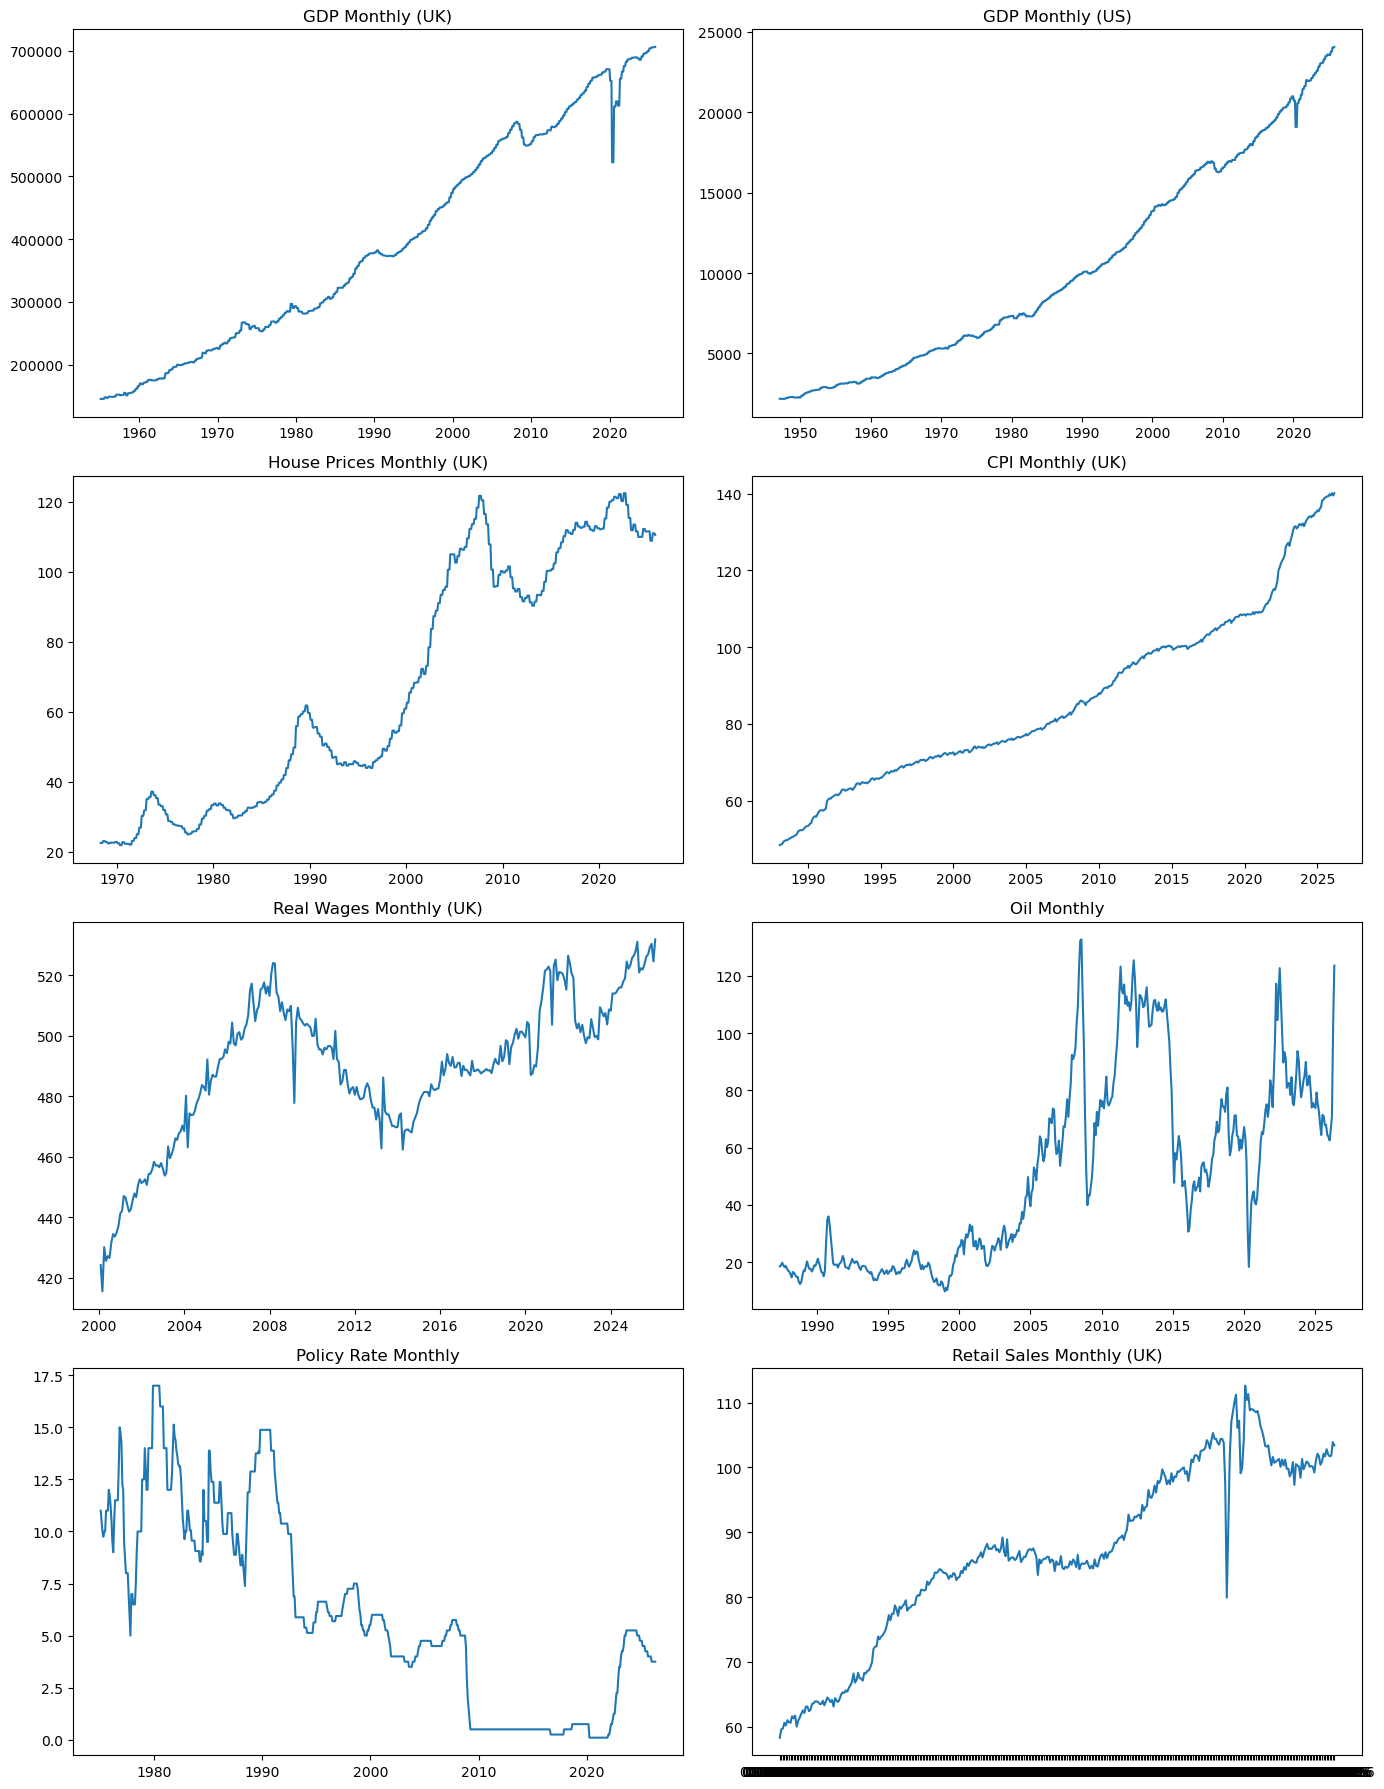

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

series_dict = {
    "GDP Monthly (UK)": gdp_monthly,
    "GDP Monthly (US)": gdp_us_monthly,
    "House Prices Monthly (UK)": house_prices_monthly,
    "CPI Monthly (UK)": cpi_monthly,
    "Real Wages Monthly (UK)": real_wages_monthly,
    "Oil Monthly": oil_monthly,
    "Policy Rate Monthly": policy_rate_monthly,
    "Retail Sales Monthly (UK)": retail_sales_monthly
}

for ax, (title, s) in zip(axes.flatten(), series_dict.items()):
    ax.plot(s.index, s.values)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Step 2.3: Create the dataframe

In [35]:
absolute_values = pd.DataFrame({

    # Economic Activity
    "gdp":            gdp_monthly,
    "gdp_us":         gdp_us_monthly,
    "house_prices":   house_prices_monthly,
    "retail_sales":   retail_sales_monthly,

    # Labour Market
    "unemployment_rate":        uk_unemployment_rate_monthly,       # %, e.g. 5.0 = 5%
    "participation_rate":       uk_labour_participation_rate_monthly,  # %, e.g. 63.0 = 63%

    # Inflation Pressure
    "cpi":            cpi_monthly,
    "real_wages":     real_wages_monthly,

    # Financial Conditions
    "policy_rate":    policy_rate_monthly,
    "yield_us_2y":    bond_yields_monthly["US_2Y"],
    "yield_us_10y":   bond_yields_monthly["US_10Y"],
    "yield_us_30y":   bond_yields_monthly["US_30Y"],
    "yield_uk_10y":   bond_yields_monthly["UK_10Y"],
    "yield_uk_3m":    bond_yields_monthly["UK_3M"],
    "spread_us_hy":   us_credit_spreads_monthly["us_hy_spread"],
    "spread_us_ig":   us_credit_spreads_monthly["us_ig_spread"],
    "spread_us_bbb":  us_credit_spreads_monthly["us_bbb_spread"],

    # Commodity Prices
    "oil":            oil_monthly,
    "gold":           gold_monthly,
    "silver":         silver_monthly,
    "copper":         copper_monthly,
    "nat_gas":        nat_gas_monthly,

    # Market Indicators
    "sox":            sox_monthly,
    "uranium":        uranium_monthly,
    "dxy":            dxy_monthly,
    "twusd":          twusd_monthly,

})

absolute_values.tail(10)

In [36]:
# Check missingness

absolute_values.isna().sum()

gdp             102
gdp_us            6
house_prices    261
cpi             494
real_wages      639
oil             484
policy_rate     336
dtype: int64

# Step 2.4: Create the signals

In [37]:
signals = pd.DataFrame(index=absolute_values.index)

signals["gdp_growth_yoy"] = absolute_values["gdp"].pct_change(12, fill_method=None) * 100
signals["gdp_growth_yoy_us"] = absolute_values["gdp_us"].pct_change(12, fill_method=None) * 100
signals["house_prices_yoy"] = absolute_values["house_prices"].pct_change(12, fill_method=None) * 100
signals["cpi_yoy"] = absolute_values["cpi"].pct_change(12, fill_method=None) * 100
signals["real_wages_yoy"] = absolute_values["real_wages"].pct_change(12, fill_method=None) * 100
signals["oil_yoy"] = absolute_values["oil"].pct_change(12, fill_method=None) * 100
signals["policy_rate_level"] = absolute_values["policy_rate"]

signals.tail(15)

# Which columns have NULLs at the start? Why? Is that acceptable?

,gdp_growth_yoy,gdp_growth_yoy_us,house_prices_yoy,cpi_yoy,real_wages_yoy,oil_yoy,policy_rate_level
2025-02-28,1.845553,2.019273,1.456352,2.796674,2.715614,-9.631383,4.50
2025-03-31,1.845553,2.019273,1.456352,2.631579,3.276353,-14.841196,4.50
2025-04-30,1.434521,2.080467,-1.026864,3.520599,1.092115,-24.242892,4.50
2025-05-31,1.434521,2.080467,-1.026864,3.360717,1.228951,-21.154736,4.25
2025-06-30,1.434521,2.080467,-1.026864,3.579418,1.148267,-13.132843,4.25
2025-07-31,1.281518,2.335168,-1.093615,3.886398,1.120558,-16.572208,4.25
2025-08-31,1.281518,2.335168,-1.093615,3.723008,1.390226,-15.537553,4.00
2025-09-30,1.281518,2.335168,-1.093615,3.800298,0.444185,-8.148451,4.00
2025-10-31,0.997434,1.989300,-0.881640,3.555556,1.360606,-14.661838,4.00
2025-11-30,NaN,NaN,NaN,3.256847,1.366266,-14.188183,4.00


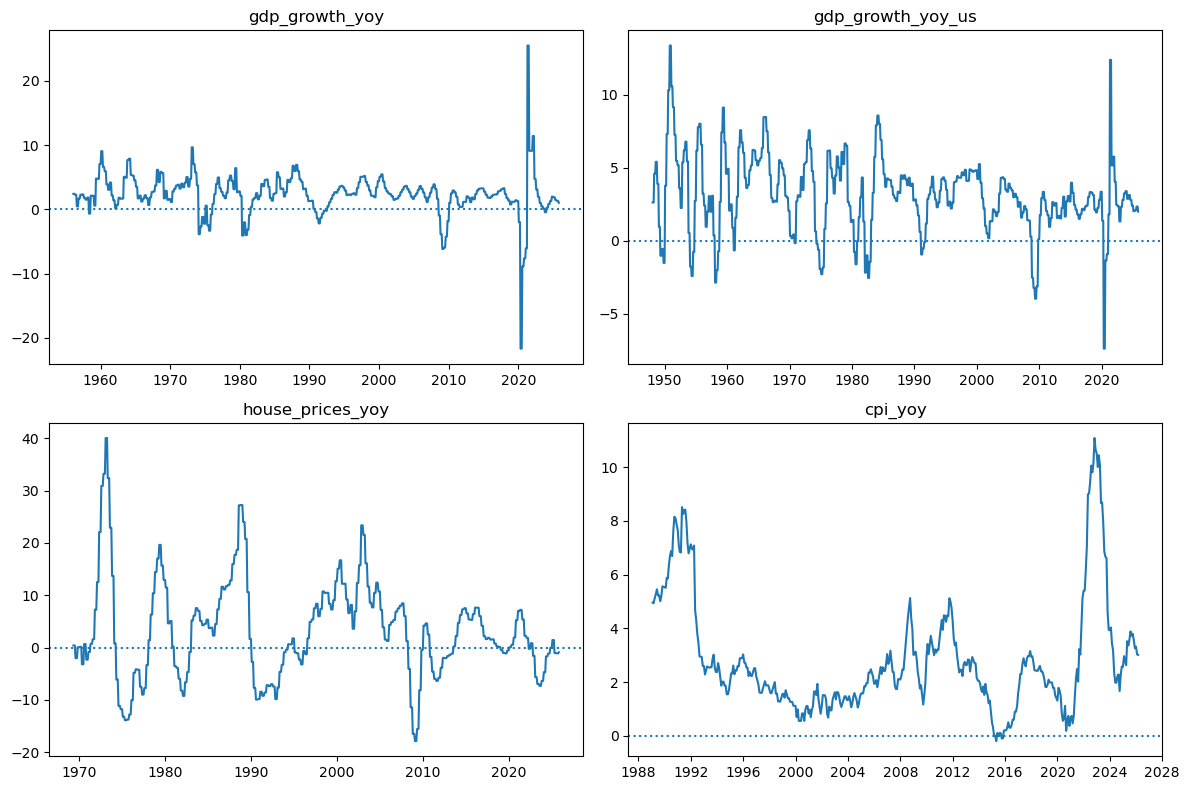

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), signals.columns):
    ax.plot(signals.index, signals[col])
    ax.axhline(0, linestyle=":")
    ax.set_title(col)

plt.tight_layout()
plt.show()

# GDP and oil oscillating around 0
# inflation clearly in the ascendancy
# Policy Rate on a short term decline
# Does that matter for later scoring?

In [39]:
absolute_values
signals

,gdp_growth_yoy,gdp_growth_yoy_us,house_prices_yoy,cpi_yoy,real_wages_yoy,oil_yoy,policy_rate_level
1947-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-31,NaN,NaN,NaN,3.318584,-0.225545,-15.319917,3.75
2026-01-31,NaN,NaN,NaN,3.028065,1.008712,-15.980826,3.75
2026-02-28,NaN,NaN,NaN,3.014706,NaN,-6.032769,3.75
2026-03-31,NaN,NaN,NaN,NaN,NaN,41.799112,3.75


# Step 3: Devise a Composite Metric

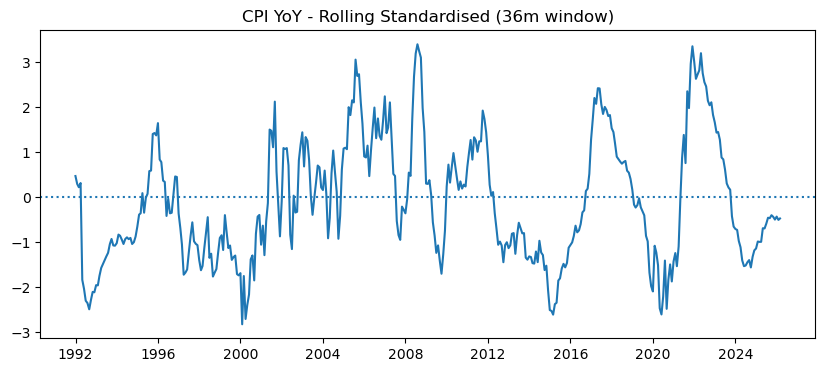

In [40]:
## Standardise one signal manually

cpi_signal = signals["cpi_yoy"].dropna()

window = 36  # 36 months (~3 years)

rolling_mean = cpi_signal.rolling(window).mean()
rolling_std = cpi_signal.rolling(window).std()

cpi_z = (cpi_signal - rolling_mean) / rolling_std

plt.figure(figsize=(10, 4))
plt.plot(cpi_z.index, cpi_z.values)
plt.axhline(0, linestyle=":")
plt.title(f"CPI YoY - Rolling Standardised ({window}m window)")
plt.show()

# Why standardise at all
# So instead of: “CPI is 6%”, you get “CPI is +1.8 standard deviations above normal”

# Why is CPI in percent not directly comparable to policy rate in percent?
# CPI YoY measures a rate of change (velocity) and policy rate measures a level
# It's how fast prices are rising vs the cost of money right now


In [41]:
# Standardise all signals

z = pd.DataFrame(index=signals.index)

for col in signals.columns:
    s = signals[col]
    z[col] = (s - s.rolling(36).mean()) / s.rolling(36).std()

# We're assuming
# Stationarity (a stable normal that doesn't change over time)
# Symmetry (upside deviations are equal to downside deviations)
# Normal distribution (most values cluster nicely, extremes are rare)
# Independence over time (no path dependency)

# If CPI sits at 2% for a long time, and suddenly spikes to 10% as it did in 2022, the mean shifts upwards, the
# standard deviation explodes, and previous years look suddenly calm in comparison

In [42]:
# Flip the signs where 'higher = worse'

z_adj = z.copy()

z_adj["cpi_yoy"] = -z_adj["cpi_yoy"]
z_adj["oil_yoy"] = -z_adj["oil_yoy"]
z_adj["policy_rate_level"] = -z_adj["policy_rate_level"]
# gdp growth stays positive because higher growth is better

# For the composite metric this is key. Building without this would create a signal that cancels itself out.
# Rising inflation, oil prices and interest rates means tightening of the economy, not prosperity

In [43]:
# Build a simple composite metric

numeric_cols = z_adj.select_dtypes(include="number").columns

z_adj["composite"] = z_adj[numeric_cols].mean(axis=1)

meta = pd.DataFrame(index=z_adj.index)

def contributing_cols(row):
    return [col for col in numeric_cols if pd.notna(row[col])]

meta["contributors"] = z_adj[numeric_cols].apply(contributing_cols, axis=1)

In [44]:
def active_contributors(row, threshold=0.5):
    return [col for col in numeric_cols if pd.notna(row[col]) and abs(row[col]) > threshold]

meta["active_contributors"] = z_adj[numeric_cols].apply(active_contributors, axis=1)

z_adj[["composite"]].join(meta).tail()

# Why use a mean? Because it's easy

# Each variable should not have equal weight:
# At different times, inflation dominates everything (2022), rates dominate everything (tightening cycles),
# growth dominates everything (recessions) and liquidity dominates everything (QE cycles)

# We lose insight on competing variables when rolling into one number
# We also lose causality, regime shifts and non-linear effects


,composite,contributors,active_contributors
2025-12-31,0.435122,"[cpi_yoy, real_wages_yoy, oil_yoy, policy_rate...","[real_wages_yoy, policy_rate_level]"
2026-01-31,0.617996,"[cpi_yoy, real_wages_yoy, oil_yoy, policy_rate...","[cpi_yoy, policy_rate_level]"
2026-02-28,0.614673,"[cpi_yoy, oil_yoy, policy_rate_level]",[policy_rate_level]
2026-03-31,-0.902400,"[oil_yoy, policy_rate_level]","[oil_yoy, policy_rate_level]"
2026-04-30,-1.299865,"[oil_yoy, policy_rate_level]","[oil_yoy, policy_rate_level]"


In [45]:
# Consider: weighted versions, for example

weights = {
    "cpi_yoy": 0.4,
    "policy_rate_level": 0.3,
    "gdp_growth_yoy": 0.2,
    "oil_yoy": 0.1
}

z_adj["weighted_composite"] = sum(z_adj[col] * w for col, w in weights.items())

# Better: build multiple composites 
# Inflation pressure index, Growth momentum index, Liquidity index

In [46]:
z_adj.tail(10)

,gdp_growth_yoy,gdp_growth_yoy_us,house_prices_yoy,cpi_yoy,real_wages_yoy,oil_yoy,policy_rate_level,composite,weighted_composite
2025-07-31,0.208883,-0.383382,0.597064,0.461415,0.184902,0.621248,0.259580,0.278530,0.366342
2025-08-31,0.285422,-0.382619,0.625812,0.471090,0.245865,0.531340,0.681429,0.351191,0.503083
2025-09-30,0.379629,-0.381856,0.656032,0.404923,-0.183903,-0.036054,0.838477,0.239607,0.485833
2025-10-31,0.040460,-1.073056,0.719590,0.441157,0.143307,0.400171,1.074833,0.249495,0.547022
2025-11-30,NaN,NaN,NaN,0.502231,0.096310,0.320702,1.238024,0.539317,NaN
2025-12-31,NaN,NaN,NaN,0.436164,-0.813894,0.368415,1.749806,0.435122,NaN
2026-01-31,NaN,NaN,NaN,0.509612,-0.246248,0.397148,1.811471,0.617996,NaN
2026-02-28,NaN,NaN,NaN,0.477654,NaN,-0.394427,1.760793,0.614673,NaN
2026-03-31,NaN,NaN,NaN,NaN,NaN,-3.482911,1.678110,-0.902400,NaN
2026-04-30,NaN,NaN,NaN,NaN,NaN,-4.202969,1.603239,-1.299865,NaN


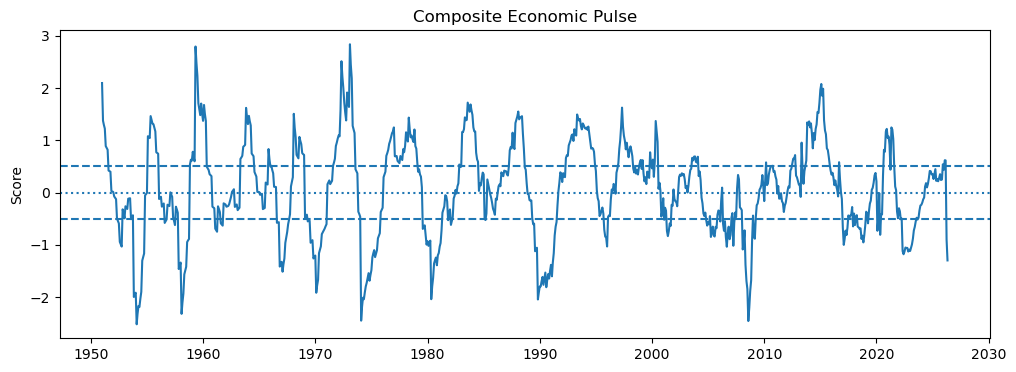

In [47]:
# Plot the composite

plt.figure(figsize=(12, 4))
plt.plot(z_adj.index, z_adj["composite"])
plt.axhline(0.5, linestyle="--")
plt.axhline(0, linestyle=":")
plt.axhline(-0.5, linestyle="--")
plt.title("Composite Economic Pulse")
plt.ylabel("Score")
plt.show()

# Multiple boom/bust cycles in the 20th century, with higher nominal growth, more active rate cycles and less QE
# Higher volatility in the dot-com bubble, much more oil volatility and monetary tightening then easing
# 2007 and COVID crises showing clearly
# 2017 looks overly healthy, because of low inflation, moderate growth and ultra-loose monetary policy

# The highs of this century do not match last century
# Pre-2000: Higher inflation tolerance, higher rates, more aggressive cycles, less intervention
# Post-2008: Lower growth, lower rates, heavy central bank intervention, suppressed volatility (until it breaks)

In [48]:
# Ensure separation
cols = ["gdp_growth_yoy", "cpi_yoy", "oil_yoy", "policy_rate_level"]

z_adj = z_adj.drop(columns=["contributors"], errors="ignore")

meta = meta.rename(columns={"contributors": "signal_contributors"})

view = (
    z_adj.loc["2016":"2018", cols + ["composite"]]
    .join(meta)
)

view.head(20)

# Looks like the data is wrong

,gdp_growth_yoy,cpi_yoy,oil_yoy,policy_rate_level,composite,signal_contributors,active_contributors
2016-01-31,-0.588367,1.008912,0.699569,NaN,0.378236,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy, gdp_growth_yoy_us, house_pric..."
2016-02-29,-0.652490,0.868472,1.042527,NaN,0.289624,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy, gdp_growth_yoy_us, house_pric..."
2016-03-31,-0.725829,0.637912,0.435080,NaN,0.140775,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy, gdp_growth_yoy_us, house_pric..."
2016-04-30,-0.291485,0.785492,0.348478,NaN,0.232013,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, house_prices_yoy, cpi_yoy,..."
2016-05-31,-0.314087,0.742170,0.185697,NaN,0.128306,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, house_prices_yoy, cpi_yoy,..."
2016-06-30,-0.337444,0.601189,-0.105110,NaN,0.053499,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, house_prices_yoy, cpi_yoy,..."
2016-07-31,-0.289483,0.342468,-0.189921,NaN,-0.074788,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, real_wages_yoy]"
2016-08-31,-0.336870,0.296772,-1.103310,5.833333,0.580277,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, oil_yoy, policy_rate_level]"
2016-09-30,-0.388991,-0.131725,-1.069552,4.065437,0.257337,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[gdp_growth_yoy_us, oil_yoy, policy_rate_level]"
2016-10-31,-0.348327,-0.184705,-1.268611,3.270236,0.008837,"[gdp_growth_yoy, gdp_growth_yoy_us, house_pric...","[house_prices_yoy, oil_yoy, policy_rate_level]"


In [49]:
# Verdict rule

latest_score = z_adj["composite"].dropna().iloc[-1]

if latest_score >= 0.5:
    verdict = "Expansion"
elif latest_score <= -0.5:
    verdict = "Contraction"
else:
    verdict = "Neutral"

latest_score, verdict

# Why -0.5 and 0.5

(-1.2998651571692488, 'Contraction')

In [50]:
# Interpreration layer

latest = z_adj.dropna().iloc[-1]

summary = {
    "GDP growth": latest["gdp_growth_yoy"],
    "Inflation pressure": latest["cpi_yoy"],
    "Oil pressure": latest["oil_yoy"],
    "Rate pressure": latest["policy_rate_level"],
    "Composite": latest["composite"]
}

summary

# Is the verdict being driven by one feature too heavily?
# Which indicator dominates?
# Is that economically reasonable?

{'GDP growth': 0.04045991726585954,
 'Inflation pressure': 0.4411572458120159,
 'Oil pressure': 0.4001710611643725,
 'Rate pressure': 1.0748328588653082,
 'Composite': 0.24949450060684691}

In [51]:
# Plain-English narrative

latest = z_adj.dropna().iloc[-1]

activity_view = "supportive" if latest["gdp_growth_yoy"] > 0 else "weak"
inflation_view = "cooling" if latest["cpi_yoy"] > 0 else "elevated"
rates_view = "supportive" if latest["policy_rate_level"] > 0 else "restrictive"

narrative = (
    f"Growth looks {activity_view}. "
    f"Inflation conditions look {inflation_view}. "
    f"Rates remain {rates_view}. "
    f"Overall verdict: {verdict}."
)

print(narrative)

Growth looks supportive. Inflation conditions look cooling. Rates remain supportive. Overall verdict: Contraction.
